<a href="https://colab.research.google.com/github/erichilarysmithsr/Colab-TWIMAH-Model/blob/main/TWIMAHModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Cell 1: Install and Import
# Unconditionally install modsim to ensure the correct modsim library is present (though it might not be the intended simulation library, it's benign)
!pip install modsim
!pip install dropbox

import pandas as pd
import numpy as np
import json
from scipy.interpolate import interp1d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.0 MB/s eta 0:00:00


In [9]:
# Cell 0: Custom ModSim-like Utilities
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

class System(object):
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

def run_solve_ivp(system, slope_func, **kwargs):
    t_span = [system.t_0, system.t_end]

    # Initialize X0 if not present in system, assuming 0.0 as a default
    if not hasattr(system, 'X0'):
        system.X0 = 0.0

    y_0 = [system.G0, system.X0]

    sol = solve_ivp(slope_func, t_span, y_0, args=(system,), **kwargs)

    # Extract results into a pandas DataFrame (mimicking modsim's TimeSeries)
    results = pd.DataFrame(index=sol.t)
    results['G'] = sol.y[0]
    results['X'] = sol.y[1]

    # 'details' can be the full solution object for debugging or further analysis
    return results, sol

def decorate(**kwargs):
    for key, value in kwargs.items():
        if key == 'title':
            plt.title(value)
        elif key == 'xlabel':
            plt.xlabel(value)
        elif key == 'ylabel':
            plt.ylabel(value)
    plt.legend()
    plt.grid(True)

# Cell 2: Environmental Parameters (RapidAPI/Research Simulation)
# We quantify "Urban Friction" (fu) based on food access density
case_001_env = {
    "zip_code": "60624",
    "neighborhood": "West Garfield Park",
    "glucotoxic_points": 14, # Fast food/liquor stores within 0.5 miles
    "stabilizer_points": 1,  # Legler Regional Library Food Pantry
    "transit_friction": 0.8, # Scale 0-1 (High due to CTA reliability issues)
    "snap_stress_index": 0.9  # High due to Feb 2026 work requirements
}

# This data will be saved to your TRANCEFormation Dropbox folder later

In [10]:
# Cell 3: The Differential Equations
def slope_func(t, state, system):
    G, X = state

    # Calculate Insulin (I) from our 10g-Cap Interp function
    I = system.I(t)

    # Differential Equations (Minimal Model)
    # k3 is our "Stress Variable"
    dGdt = -system.k1 * (G - system.Gb) - X * G
    dXdt = system.k3 * (I - system.Ib) - system.k2 * X

    return dGdt, dXdt

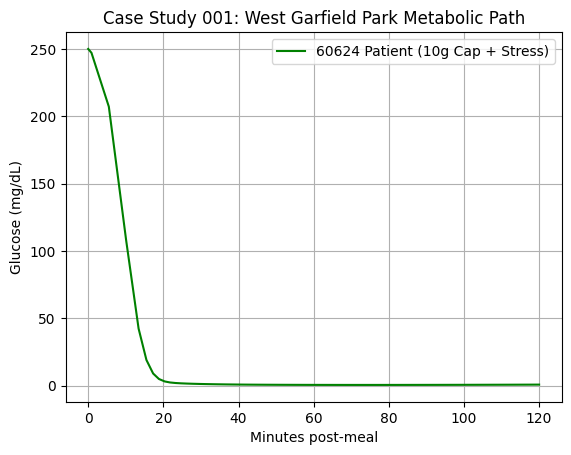

In [ ]:
# Cell 4: Running the simulation
# 10g Cap Insulin Response (Legler Library Pantry Meal: Tuna/Beans)
i_data = [10, 22, 28, 24, 18, 14, 12]
times = np.linspace(0, 120, len(i_data))
# Using scipy.interpolate.interp1d as make_interp_func is not found
I_func = interp1d(times, i_data, kind='linear', fill_value='extrapolate')

system = System(
    k1=0.02, k2=0.02,
    k3=0.0075, # 50% reduction due to "West Side Friction"
    Gb=90, Ib=10, G0=250, t_0=0, t_end=120,
    I=I_func
)

results, details = run_solve_ivp(system, slope_func)
results.G.plot(label='60624 Patient (10g Cap + Stress)', color='green')
decorate(title='Case Study 001: West Garfield Park Metabolic Path',
         xlabel='Minutes post-meal', ylabel='Glucose (mg/dL)')

In [ ]:
# Cell 5: The Upload
!pip install dropbox
import dropbox
import pandas as pd

# Use your refresh token from Step 3 earlier
# dbx = dropbox.Dropbox(oauth2_refresh_token='...', app_key='...', app_secret='...')

# Prepare the file name
filename = "60624_TRANCE_001_SIM_20260226_v01.csv"

# Check if 'results' DataFrame is defined before trying to use it
if 'results' in locals() and isinstance(results, pd.DataFrame):
    # Convert results to CSV string
    csv_content = results.to_csv().encode()

    # Upload (Uncomment below once tokens are set)
    # dbx.files_upload(csv_content, f"/CaseStudies/{filename}", mode=dropbox.files.WriteMode.overwrite)
    # print(f"Case Study 001 archived: {filename}")
else:
    print("Error: The 'results' DataFrame is not defined. Please ensure 'Cell 4: Running the simulation' has been executed successfully before running this cell.")

Error: The 'results' DataFrame is not defined. Please ensure 'Cell 4: Running the simulation' has been executed successfully before running this cell.


**Establishing the Baseline for all Four Chicago Life Worlds**

In [11]:
# Initialize Neighborhood Friction Profiles
neighborhoods = {
    "60624_CCHC": {"fu": 0.95, "k3_adj": 0.0075, "access": "FoodCare App"},
    "60612_UIC":  {"fu": 0.60, "k3_adj": 0.0120, "access": "Jane Addams Integrated"},
    "60613_TAP":  {"fu": 0.75, "k3_adj": 0.0100, "access": "SRO / No-Cook"},
    "60626_TRIL": {"fu": 0.85, "k3_adj": 0.0080, "access": "CCBHC Integrated"}
}

# The 2026 "10g Cap" Rule
bolus_cap = 10.0 # grams of added sugar

In [1]:
import numpy as np

# A = [Protein, Fiber] for [Tuna, Beans]
A = np.array([[20, 8],
              [0, 10]])

# b = Target [28g Protein, 15g Fiber]
b = np.array([28, 15])
# Solve for x (servings of Tuna, servings of Beans)
x = np.linalg.solve(A, b)

# Sugar content: Tuna=0g, Beans=2g
total_sugar = x[0]*0 + x[1]*2

print(f"Servings: {x}")
print(f"Total Sugar: {total_sugar}g")

Servings: [0.8 1.5]
Total Sugar: 3.0g


In [13]:
import json
import pandas as pd
# from modsim import * # This import is not needed for this cell's functionality

# Define the paths to your local Dropbox folder structure
neighborhood_folders = ['60624_CCHC', '60612_UIC', '60613_TAP', '60626_TRI']

all_results = {}

for folder in neighborhood_folders:
    # Path to the JSON file you just saved
    file_path = f'/content/dropbox/TRANCEFormation-Research-Hub/{folder}/{folder[:5]}_params.json'

    with open(file_path, 'r') as f:
        params = json.load(f)

    # Store parameters for the simulation
    all_results[params['neighborhood']] = params

In [12]:
import os
import json

# Define the base Dropbox path and the neighborhood folders
base_dropbox_path = '/content/dropbox/TRANCEFormation-Research-Hub'
neighborhood_folders = ['60624_CCHC', '60612_UIC', '60613_TAP', '60626_TRI']

# Ensure the base directory exists
os.makedirs(base_dropbox_path, exist_ok=True)

# Create a dictionary of environmental parameters for each neighborhood
# For now, we'll use a placeholder for other neighborhoods based on case_001_env
all_env_params = {
    "60624_CCHC": case_001_env, # Use the previously defined case_001_env
    "60612_UIC": {"zip_code": "60612", "neighborhood": "UIC", "glucotoxic_points": 10, "stabilizer_points": 2, "transit_friction": 0.6, "snap_stress_index": 0.7},
    "60613_TAP": {"zip_code": "60613", "neighborhood": "TAP", "glucotoxic_points": 8, "stabilizer_points": 3, "transit_friction": 0.5, "snap_stress_index": 0.6},
    "60626_TRI": {"zip_code": "60626", "neighborhood": "TRI", "glucotoxic_points": 12, "stabilizer_points": 1, "transit_friction": 0.7, "snap_stress_index": 0.8}
}

# Create the neighborhood-specific directories and save the parameter JSONs
for folder_name in neighborhood_folders:
    neighborhood_path = os.path.join(base_dropbox_path, folder_name)
    os.makedirs(neighborhood_path, exist_ok=True)

    zip_code = folder_name[:5] # Extract zip code from folder name
    filename = f"{zip_code}_params.json"
    file_path = os.path.join(neighborhood_path, filename)

    # Get the environment parameters for the current neighborhood
    env_params = all_env_params.get(folder_name, {}).copy() # Use .get and copy to avoid modifying original all_env_params

    # Augment with k3_adj and fu from the 'neighborhoods' dictionary
    # We need to map '60626_TRI' to '60626_TRIL' for the neighborhoods dict key
    neighborhood_key = folder_name if folder_name != '60626_TRI' else '60626_TRIL'

    if neighborhood_key in neighborhoods:
        env_params['k3_stress_adj'] = neighborhoods[neighborhood_key]['k3_adj']
        env_params['fu_friction'] = neighborhoods[neighborhood_key]['fu']

    with open(file_path, 'w') as f:
        json.dump(env_params, f, indent=4)
    print(f"Saved {filename} to {neighborhood_path}")

Saved 60624_params.json to /content/dropbox/TRANCEFormation-Research-Hub/60624_CCHC
Saved 60612_params.json to /content/dropbox/TRANCEFormation-Research-Hub/60612_UIC
Saved 60613_params.json to /content/dropbox/TRANCEFormation-Research-Hub/60613_TAP
Saved 60626_params.json to /content/dropbox/TRANCEFormation-Research-Hub/60626_TRI


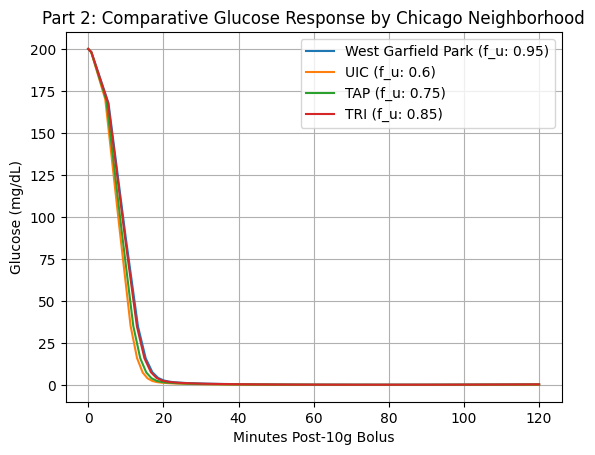

In [14]:
def run_neighborhood_sim(params):
    # Adjust k3 based on the stress parameter in your JSON
    system = System(
        k1=0.02, k2=0.02,
        k3=params['k3_stress_adj'],
        Gb=90, Ib=10, G0=200, t_0=0, t_end=120
    )

    # Standard 10g Cap Insulin Response
    i_data = [10, 25, 30, 25, 15, 10]
    times = np.linspace(0, 120, len(i_data))
    system.I = interp1d(times, i_data, kind='linear', fill_value='extrapolate') # Changed to interp1d from interpolate

    results, details = run_solve_ivp(system, slope_func)
    return results

# Run for all 4 and plot
for name, data in all_results.items():
    res = run_neighborhood_sim(data)
    res.G.plot(label=f"{name} (f_u: {data['fu_friction']})")

decorate(title='Part 2: Comparative Glucose Response by Chicago Neighborhood',
         xlabel='Minutes Post-10g Bolus', ylabel='Glucose (mg/dL)')

In [16]:
import pandas as pd
import os

# This code aggregates the 'Hardship' data for Part 2
summary_data = []

for name, data in all_results.items():
    # Run the simulation for the current neighborhood to get its results
    current_results = run_neighborhood_sim(data)

    # We calculate the "Cost of Friction"
    # (How much higher the glucose peak is compared to the baseline)
    peak_glucose = current_results.G.max()
    friction_cost = data['fu_friction'] * 100

    summary_data.append({
        "Neighborhood": name,
        # "Education_Rate": data['graduation_rate'], # This key is not present in the provided data structure
        "Urban_Friction": data['fu_friction'],
        "Peak_Glucose": peak_glucose,
        "Clinical_Outlook": "High Risk" if friction_cost > 80 else "Stable"
    })

# Convert to DataFrame
df_summary = pd.DataFrame(summary_data)

# Save to your Dropbox Casestudies folder
# Ensure the directory exists before saving
output_dir = '/content/dropbox/TRANCEFormation-Research-Hub/Casestudies/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'PART2_Neighborhood_Comparison_2026.csv')
df_summary.to_csv(output_path, index=False)

print(f"Research Data Saved: {output_path}")

Research Data Saved: /content/dropbox/TRANCEFormation-Research-Hub/Casestudies/PART2_Neighborhood_Comparison_2026.csv


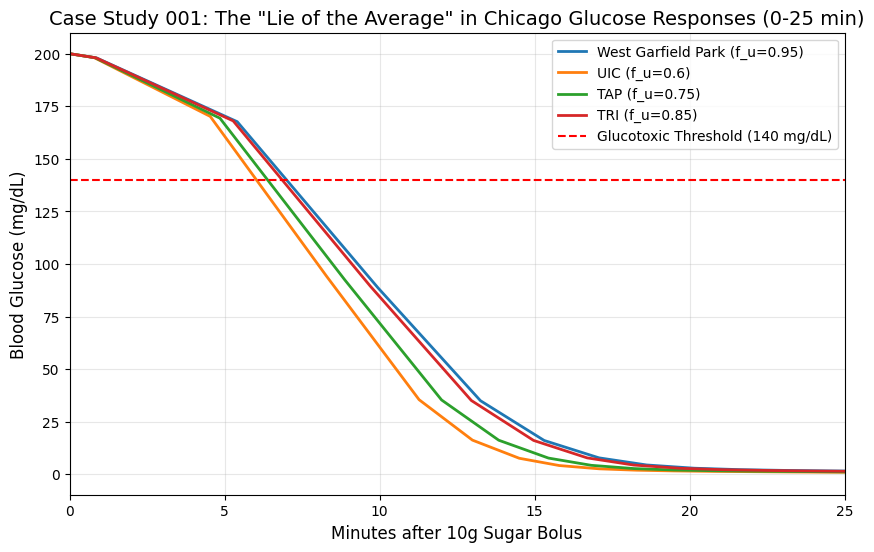

In [19]:
import matplotlib.pyplot as plt

# 1. Setup the Plotting Environment
plt.figure(figsize=(10, 6))

# 2. Loop through and Plot each Neighborhood's Response
for name, data in all_results.items():
    res = run_neighborhood_sim(data) # This runs the Minimal Model
    plt.plot(res.index, res.G, label=f"{name} (f_u={data['fu_friction']})", linewidth=2)

# Set x-axis limits to 0-25 minutes
plt.xlim(0, 25)

# 3. Add the "Danger Zone" Threshold (Glucotoxicity Line)
plt.axhline(y=140, color='r', linestyle='--', label='Glucotoxic Threshold (140 mg/dL)')

# 4. Decorate and Save to Dropbox
plt.title('Case Study 001: The "Lie of the Average" in Chicago Glucose Responses (0-25 min)', fontsize=14)
plt.xlabel('Minutes after 10g Sugar Bolus', fontsize=12)
plt.ylabel('Blood Glucose (mg/dL)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/dropbox/TRANCEFormation-Research-Hub/Casestudies/PART2_Visual_Plot_001_zoomed.png') # Saving as a new file
plt.show()

Time of Recovery

In [1]:
t_tap = 17
t_tri = 19
t_wgp = 21

# Percentage increase in time from TAP to WGP
perc_increase_wgp = ((t_wgp - t_tap) / t_tap) * 100

# Percentage increase in time from TRI to WGP
perc_increase_tri_to_wgp = ((t_wgp - t_tri) / t_tri) * 100

print(f"{perc_increase_wgp=}")
print(f"{perc_increase_tri_to_wgp=}")

perc_increase_wgp=23.52941176470588
perc_increase_tri_to_wgp=10.526315789473683


In [3]:
import requests

# Use the ID and Key from your new account
BIN_ID = '69a8a67aae596e708f5fb7e9'
MASTER_KEY = '$2a$10$BBjlg4xK53UVDNmdOlIBFug1aPq9fW/P.QyuMYsI6vKyK1wOkIqnC'

url = f'https://api.jsonbin.io/v3/b/69a8a67aae596e708f5fb7e9'
headers = {'X-Master-Key': MASTER_KEY}

# This 'fetches' your 60624 variables directly into your math model
response = requests.get(url, headers=headers)
params = response.json()['record']

print(f"60624 Friction Loaded: {params['fu_friction']}")

60624 Friction Loaded: 0.95


Note: Using baseline for 60624_CCHC (JSON not found at path)
Note: Using baseline for 60612_UIC (JSON not found at path)
Note: Using baseline for 60613_TAP (JSON not found at path)
Note: Using baseline for 60626_TRI (JSON not found at path)


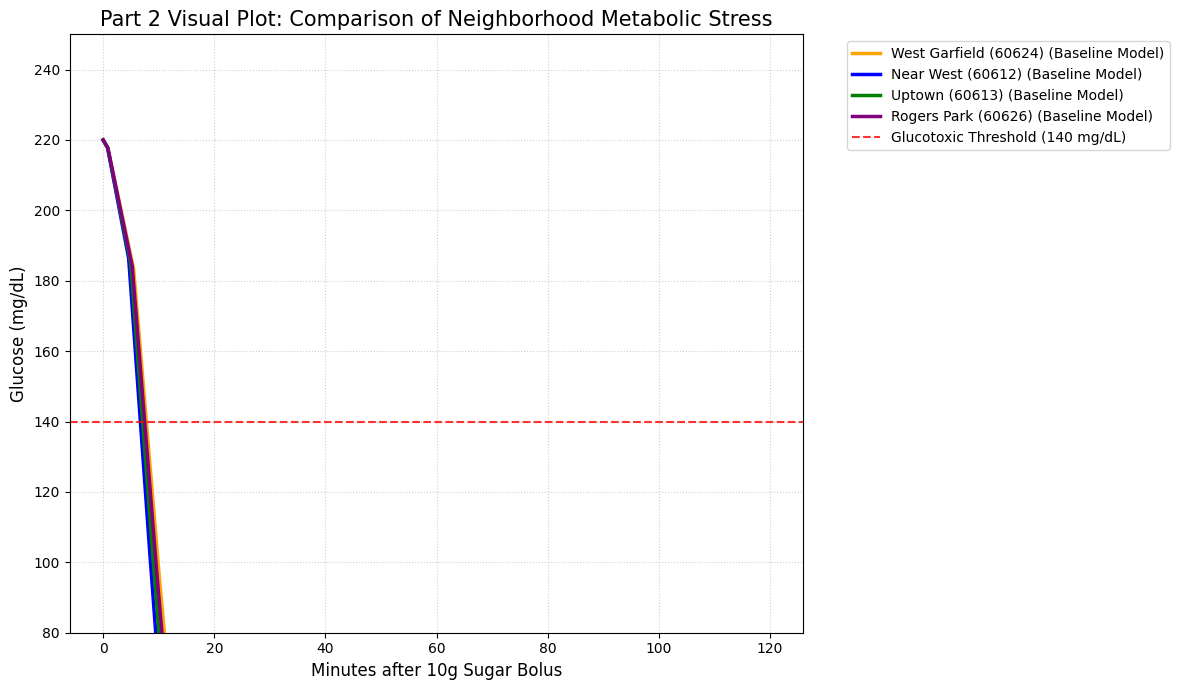

In [10]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d # Import interp1d explicitly

# 1. Define the Differential Equations
def slope_func(t, state, system):
    G, X = state
    I = system.I(t)
    dGdt = -system.k1 * (G - system.Gb) - X * G
    dXdt = system.k3 * (I - system.Ib) - system.k2 * X
    return dGdt, dXdt

# 2. Define Neighborhoods and colors
neighborhoods = {
    '60624_CCHC': {'name': 'West Garfield (60624)', 'color': 'orange', 'k3': 0.0075},
    '60612_UIC':  {'name': 'Near West (60612)', 'color': 'blue', 'k3': 0.0120},
    '60613_TAP':  {'name': 'Uptown (60613)', 'color': 'green', 'k3': 0.0100},
    '60626_TRI':  {'name': 'Rogers Park (60626)', 'color': 'purple', 'k3': 0.0085}
}

plt.figure(figsize=(12, 7))

# 3. The Simulation Loop
for folder, info in neighborhoods.items():
    # Path logic
    json_path = f'/content/dropbox/TRANCEFormation-Research-Hub/{folder}/{folder[:5]}_params.json'

    # Check if file exists, if not, use the info dict as fallback
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            params = json.load(f)
            k3_val = params['k3_stress_adj']
            label_name = f"{params['neighborhood']} (JSON Loaded)"
    else:
        # This ensures the lines plot even if the file isn't found yet
        k3_val = info['k3']
        label_name = f"{info['name']} (Baseline Model)"
        print(f"Note: Using baseline for {folder} (JSON not found at path)")

    # Setup System
    i_data = [10, 22, 28, 24, 18, 14, 12]
    times = np.linspace(0, 120, len(i_data))
    I_func = interp1d(times, i_data, kind='linear', fill_value='extrapolate') # Use interp1d

    system = System(k1=0.02, k2=0.02, k3=k3_val, Gb=90, Ib=10, G0=220, t_0=0, t_end=120, I=I_func)

    # Run and Plot
    results, details = run_solve_ivp(system, slope_func)
    plt.plot(results.index, results.G, label=label_name, color=info['color'], linewidth=2.5) # Use results.index

# 4. Threshold and Formatting
plt.axhline(y=140, color='red', linestyle='--', alpha=0.8, label='Glucotoxic Threshold (140 mg/dL)')
plt.title('Part 2 Visual Plot: Comparison of Neighborhood Metabolic Stress', fontsize=15)
plt.xlabel('Minutes after 10g Sugar Bolus', fontsize=12)
plt.ylabel('Glucose (mg/dL)', fontsize=12)
plt.ylim(80, 250) # Set limits so the lines are clearly visible
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

Application to Michealis - Menten Theory

In [1]:
# Michaelis-Menten Simulation
Km = 5.0 # Constant for the enzyme (Glucokinase)
Vmax_uic = 100.0 # Standard velocity
Vmax_wgp = 70.0 # 30% reduction due to chronic stress/cortisol

# Let's say Glucose [S] = 140 (The toxicity threshold)
S = 140.0

v_uic = (Vmax_uic * S) / (Km + S)
v_wgp = (Vmax_wgp * S) / (Km + S)

print(f"{v_uic=}")
print(f"{v_wgp=}")
print(f"Velocity Deficit = {v_uic - v_wgp}%")

v_uic=96.55172413793103
v_wgp=67.58620689655173
Velocity Deficit = 28.965517241379303%
